In [18]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
# Standard library imports
import os                          # For interacting with the operating system
from pathlib import Path           # For handling file system paths
import warnings                    # For managing warnings
import import_ipynb                # For importing Jupyter notebooks as modules

# Third-party library imports
import matplotlib.pyplot as plt    # For plotting graphs and images
import numpy as np                 # For numerical operations
from sklearn.model_selection import train_test_split  # For splitting datasets into training and testing sets


# Custom utility functions
from utils import (
    load_images_and_masks,         # Function to load images and masks
    view_data,                     # Function to visualize data
    preprocess_images_and_masks,   # Function to preprocess images and masks
    remap_mask_classes,            # Function to remap mask classes
    save_datasets,                 # Function to save presplit datasets
    load_datasets,                 # Function to load presplit datasets
    save_associated_files,         # Function to save associated files
    custom_warnings,               # Function to format custom warnings
)

# Custom U-Net related functions
from unet_weighted_loss_output import (
    unet_model,                    # Function to create the U-Net model
    test_unet,                     # Function to test the U-Net model
    plot_losses,                   # Function to plot training losses
    save_predicted_masks,          # Function to save predicted masks
    iou_metric,                    # Function to calculate Intersection over Union
    dice_coeff,                    # Function to calculate Dice coefficient
)

def get_dataset_name_from_path(path):
    # removes trailing slash if it exists
    path = path.rstrip(os.sep)
    return os.path.basename(path)

# Optional line to suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# TensorFlow and Keras imports
from tensorflow.keras import callbacks, optimizers  # For handling callbacks and optimizers in Keras
import tensorflow as tf                             # TensorFlow library

# Force the warnings library to use the custom warnings format
warnings.formatwarning = custom_warnings

In [20]:
# Force all seed values to be the same. This should only be done when testing.
PRODUCTION = False  # Flag to indicate whether the environment is production or not

# Seed value for reproducibility
seed_value = 42

# If not in production, set the seed values to ensure reproducibility
if not PRODUCTION:
    np.random.seed(seed_value) # Set the seed for NumPy's random number generator
    tf.random.set_seed(seed_value) # Set the seed for TensorFlow's random number generator
    os.environ["PYTHONHASHSEED"] = str(seed_value) # Set the seed for Python's built-in hash function    

In [21]:
# Set the necessary directories. These should be relative to the working directory
images_dir = "Datasets/Pala_Mesa_Roads_Rails/images"  # Directory for images
masks_dir = "Datasets/Pala_Mesa_Roads_Rails/labels"  # Directory for masks
model_dir = "models"  # Directory for saving the model
model_name = "trained_UNet_merged.keras"  # Model file name
model_path = Path(f"{model_dir}/{model_name}")  # Full path to the model file as a Path object

In [22]:
# Load the images and masks
images, masks, missing_masks, names_map = load_images_and_masks(
    images_dir,          # Directory containing the images
    masks_dir,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=1000,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

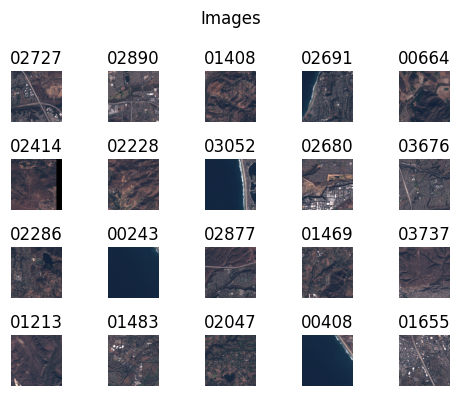

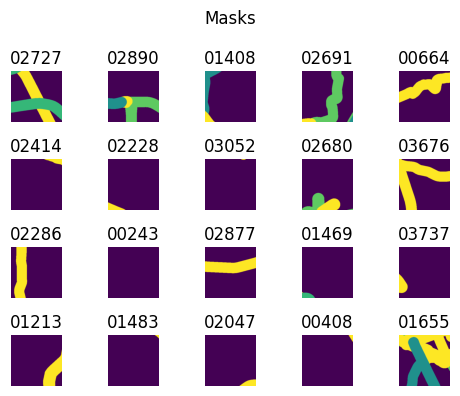

In [23]:
# View images and masks
view_data(
    images=images,       # List of images to view
    masks=masks,         # List of masks to view
    max_plots=20,        # Maximum number of plots to display
    max_cols=5,          # Maximum number of columns in the plot grid
    randomize=True,      # Whether to randomize the order of the images and masks
    colors=True          # Whether to display the masks in color
)

In [24]:
# Set the necessary directories. These should be relative to the working directory
images_dir2 = "Datasets/ThousandOaks/Z2_Roads_Rails_Woosley/images"  # Directory for images
masks_dir2 = "Datasets/ThousandOaks/Z2_Roads_Rails_Woosley/labels"  # Directory for masks

# Load the images and masks
images2, masks2, missing_masks2, names_map2 = load_images_and_masks(
    images_dir2,          # Directory containing the images
    masks_dir2,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=1000,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

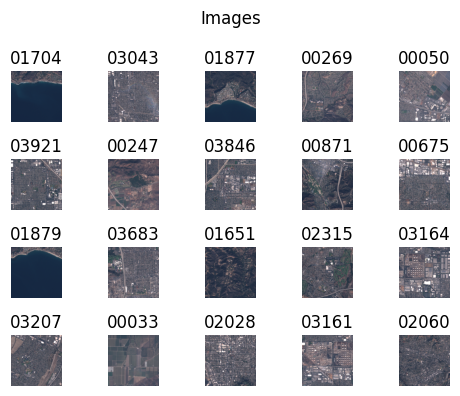

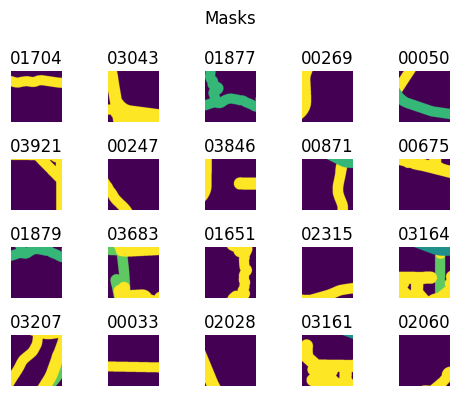

In [25]:
# View images and masks
view_data(
    images=images2,       # List of images to view
    masks=masks2,         # List of masks to view
    max_plots=20,        # Maximum number of plots to display
    max_cols=5,          # Maximum number of columns in the plot grid
    randomize=True,      # Whether to randomize the order of the images and masks
    colors=True          # Whether to display the masks in color
)

In [26]:
# Combine both datasets
import shutil

def merge_datasets(dataset_roots, out_img_dir, out_mask_dir):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_mask_dir, exist_ok=True)

    counter = 0

    for dataset_name, root in dataset_roots.items():
        img_dir = os.path.join(root, "images")
        mask_dir = os.path.join(root, "labels")

        img_files = set(f for f in os.listdir(img_dir) if f.endswith(".tif"))
        mask_files = set(f for f in os.listdir(mask_dir) if f.endswith(".tif"))

        common_files = sorted(img_files & mask_files)

        missing_masks = img_files - mask_files
        missing_images = mask_files - img_files

        if missing_masks:
            print(f"[{dataset_name}] Missing masks for {len(missing_masks)} images")
        if missing_images:
            print(f"[{dataset_name}] Extra masks without images: {len(missing_images)}")

        for fname in common_files:
            img_path = os.path.join(img_dir, fname)
            mask_path = os.path.join(mask_dir, fname)

            new_name = f"{counter:05d}.tif"

            shutil.copy2(img_path, os.path.join(out_img_dir, new_name))
            shutil.copy2(mask_path, os.path.join(out_mask_dir, new_name))

            counter += 1

    print(f"\nTotal merged pairs: {counter}")


# Define dataset roots
datasets = {
    "Pala Mesa": "Datasets/Pala_Mesa_Roads_Rails",
    "Woosley": "Datasets/ThousandOaks/Z2_Roads_Rails_Woosley"
}

# Output directories
output_images = "Datasets/merged/images"
output_masks  = "Datasets/merged/labels"

# Run merge
merge_datasets(datasets, output_images, output_masks)


Total merged pairs: 3750


In [27]:
# Set the necessary directories. These should be relative to the working directory
images_dir3 = "Datasets/merged/images"  # Directory for images
masks_dir3 = "Datasets/merged/labels"  # Directory for masks

# Load the images and masks
images3, masks3, missing_masks3, names_map3 = load_images_and_masks(
    images_dir3,          # Directory containing the images
    masks_dir3,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=1000,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

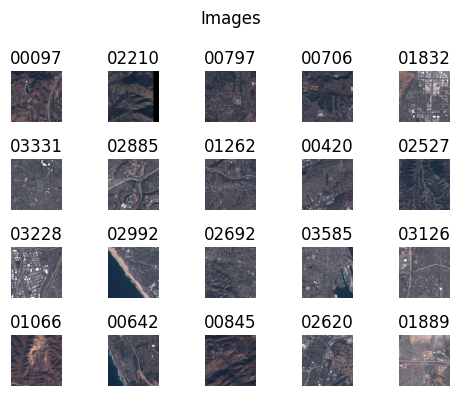

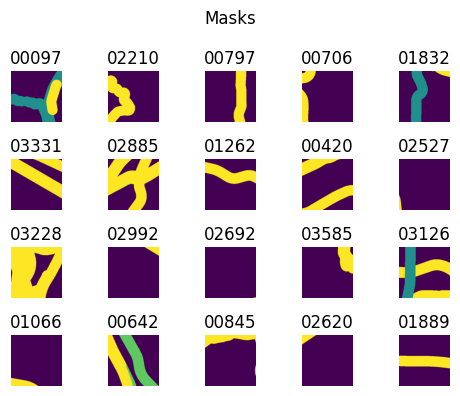

In [28]:
# View images and masks
view_data(
    images=images3,       # List of images to view
    masks=masks3,         # List of masks to view
    max_plots=20,        # Maximum number of plots to display
    max_cols=5,          # Maximum number of columns in the plot grid
    randomize=True,      # Whether to randomize the order of the images and masks
    colors=True          # Whether to display the masks in color
)

In [29]:
# Optional remapping of classes
REMAP_CLASSES = False  # Flag to indicate whether to remap classes
class_mapping = {0: 0, 1: 1, 2: 1, 3: 1}  # Dictionary mapping old classes to new classes
if REMAP_CLASSES:
    masks, num_classes = remap_mask_classes(masks, class_mapping)  # Remap the classes in the masks
    view_data(masks=masks, max_plots=20, max_cols=5, randomize=False, colors=True)  # View the remapped masks

In [30]:
# Preprocess the data for the U-Net
# Assign default values to the number of classes
num_classes = 5 

# Preprocess images and masks for the U-Net model
preprocessed_images, preprocessed_masks, threshold, image_names, num_classes = (
    preprocess_images_and_masks(
        images3,                   # List of images to preprocess
        masks3,                    # List of masks to preprocess
        num_classes=num_classes,  # Number of classes
        threshold=0.5             # Threshold value for binarizing masks
    )
)

Preprocessed data information:
Number of images: 1000.
Shape of images dataset: (1000, 256, 256, 3).
Images type: float32.
Number of masks: 1000.
Shape of masks dataset: (1000, 256, 256, 5).
Masks type: float32.
Number of classes: 5.


In [31]:
# Splitting the data into training, validation, and test
LOAD_DATASETS = False  # Flag to indicate whether to load preprocessed and presplit data
load_dir = "Datasets/merged"  # Directory to load preprocessed data from

SAVE_DATASETS = True  # Flag to indicate whether to save the datasets
save_dir = "Datasets/merged"  # Directory to save the datasets to

if LOAD_DATASETS:
    # Load in preprocessed and presplit data
    (
        images_train,        # Training images
        masks_train,         # Training masks
        images_test,         # Test images
        masks_test,          # Test masks
        images_validation,   # Validation images
        masks_validation,    # Validation masks
    ) = load_datasets(load_dir=load_dir)  # Load datasets from the specified directory
else:
    # Split out the training data
    (
        images_train,            # Training images
        images_test_and_val,     # Combined test and validation images
        masks_train,             # Training masks
        masks_test_and_val,      # Combined test and validation masks
        names_train,             # Training image names
        names_test_and_val,      # Combined test and validation image names
    ) = train_test_split(
        preprocessed_images,     # Preprocessed images
        preprocessed_masks,      # Preprocessed masks
        image_names,             # Image names
        test_size=0.2,           # Proportion of data to be used for testing and validation
        random_state=seed_value, # Seed value for reproducibility
    )

    # Split the remaining data into validation and test
    (
        images_validation,       # Validation images
        images_test,             # Test images
        masks_validation,        # Validation masks
        masks_test,              # Test masks
        names_validation,        # Validation image names
        names_test,              # Test image names
    ) = train_test_split(
        images_test_and_val,     # Combined test and validation images
        masks_test_and_val,      # Combined test and validation masks
        names_test_and_val,      # Combined test and validation image names
        test_size=0.5,           # Proportion of data to be used for testing
        random_state=seed_value, # Seed value for reproducibility
    )

# If SAVE_DATASETS is True, then save the data to the save_dir
if SAVE_DATASETS:
    save_datasets(
        training=(images_train, masks_train),             # Training images and masks
        test=(images_test, masks_test),                   # Test images and masks
        validation=(images_validation, masks_validation), # Validation images and masks
        save_dir=save_dir,                                # Directory to save the datasets to
    )

Data saved in Datasets/merged.


In [32]:
# Build the U-Net
# Specify the details of the optimizer
optimizer = optimizers.Adam(learning_rate=1e-4)  # Adam optimizer with a learning rate of 1e-4

# Create the model
# NOTE: We have chosen to use some custom metrics iou_metric and dice_coeff. The default value is ["accuracy"].
metrics = [iou_metric, dice_coeff]  # List of custom metrics to use
custom_objects = {"iou_metric": iou_metric, "dice_coeff": dice_coeff}  # Custom objects for loading the model, later on if desired. 

model = unet_model(
    the_weights = [0.27, 7.31/8, 2.73/8, 3.87/8, 2.13/8],
    input_shape=(256, 256, 3),  # Input shape of the images
    num_classes=num_classes,    # Number of classes
    num_blocks=4,               # Number of blocks in the U-Net model
    optimizer=optimizer,        # Optimizer to use
    metrics=metrics,            # Metrics to use
)

# Get a print out of the model structure.
model.summary()  # Print the summary of the model


Weights:  [0.27, 0.91375, 0.34125, 0.48375, 0.26625]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,379,205 (119.70 MB)

 Trainable params: 31,379,205 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Assign specific training parameters

# Learning rate scheduler to adjust the learning rate if the validation loss is not improving
learning_rate_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss",  # Monitor the validation loss
    factor=0.5,          # Factor by which the learning rate will be reduced
    patience=5,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,         # Minimum learning rate
    verbose=1            # Verbosity mode
)

# Stop the model early, and keep the best results, if the validation loss is not improving
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",  # Monitor the validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best validation loss
)

# Save the best model as determined by the validation loss. The default save frequency is every epoch
checkpoint = callbacks.ModelCheckpoint(
    model_path,          # Path to save the model
    save_best_only=True, # Save only the best model
    monitor="val_loss"   # Monitor the validation loss
)

# Gather the model callbacks into a single variable
model_callbacks = [learning_rate_scheduler, early_stop, checkpoint]

# Assign the training settings
epochs = 25          # Number of epochs to train the model
batch_size = 8       # Batch size for training
model_verbosity = 1  # Verbosity mode for training

In [34]:
# Train the model
model_fit = model.fit(
    images_train,                # Training images
    masks_train,                 # Training masks
    batch_size=batch_size,       # Batch size for training
    epochs=epochs,               # Number of epochs to train the model
    validation_data=(images_validation, masks_validation),  # Validation data
    callbacks=model_callbacks,   # List of callbacks to apply during training
    verbose=model_verbosity,     # Verbosity mode for training
)

Epoch 1/25


I0000 00:00:1778116254.611413 4004508 service.cc:152] XLA service 0x1553f800ade0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778116254.611447 4004508 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-05-06 21:10:54.719838: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778116255.342474 4004508 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/100 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - dice_coeff: 0.2036 - iou_metric: 0.1134 - loss: 0.4817

I0000 00:00:1778116269.351118 4004508 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - dice_coeff: 0.4493 - iou_metric: 0.2942 - loss: 0.3653 - val_dice_coeff: 0.5157 - val_iou_metric: 0.3487 - val_loss: 0.3480 - learning_rate: 1.0000e-04
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - dice_coeff: 0.5179 - iou_metric: 0.3514 - loss: 0.3333 - val_dice_coeff: 0.5922 - val_iou_metric: 0.4229 - val_loss: 0.3573 - learning_rate: 1.0000e-04
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - dice_coeff: 0.5275 - iou_metric: 0.3603 - loss: 0.3279 - val_dice_coeff: 0.5802 - val_iou_metric: 0.4109 - val_loss: 0.3470 - learning_rate: 1.0000e-04
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - dice_coeff: 0.5319 - iou_metric: 0.3645 - loss: 0.3245 - val_dice_coeff: 0.5712 - val_iou_metric: 0.4019 - val_loss: 0.3397 - learning_rate: 1.0000e-04
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - dice_coeff: 0.5365 - iou_metric: 0.3689 - loss: 0.3195 - val_dice_coeff: 0.5490 - val_iou_metric: 0.3802 - val_loss: 0.325

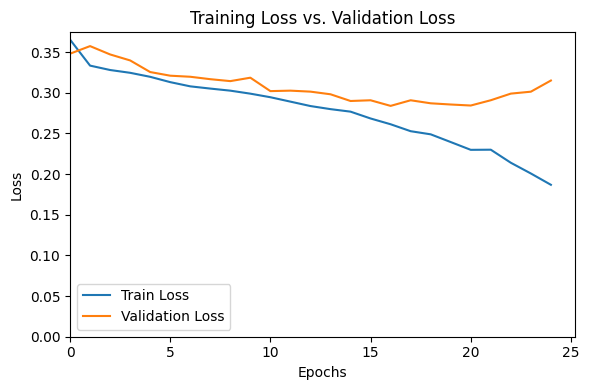

In [35]:
# View model losses
plot_losses(model_fit)  # Function to plot the training and validation losses over epochs, from unet.ipynb

In [37]:
# Optional loading of a model
# NOTE: If you have used custom metrics, you must explicitly load them back in with the model.
LOAD_MODEL = False  # Flag to indicate whether to load a pre-trained model
if LOAD_MODEL:
    model = tf.keras.models.load_model(
        model_path,                    # Path to the saved model
        custom_objects=custom_objects  # Custom objects (e.g., custom metrics) to load with the model
    )

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step
Metrics based on test data:

Class Background Individual Metrics:
Precision: 0.7558299919398203
Recall: 0.9873652870670375
F1 Score: 0.8562211083897748

Class Low to Moderate Risk Individual Metrics:
Precision: 0.4091731676897117
Recall: 0.16205941322898404
F1 Score: 0.2321659011752952

Class High Risk Individual Metrics:
Precision: 0.5892575750754131
Recall: 0.04292653488272935
F1 Score: 0.08002347877127763

Class Very High Risk Individual Metrics:
Precision: 0.22697146960697775
Recall: 0.09910180618610576
F1 Score: 0.13796458808872075

Class Extreme Risk Individual Metrics:
Precision: 0.5396174308573285
Recall: 0.021018512806154167
F1 Score: 0.040461037181400164



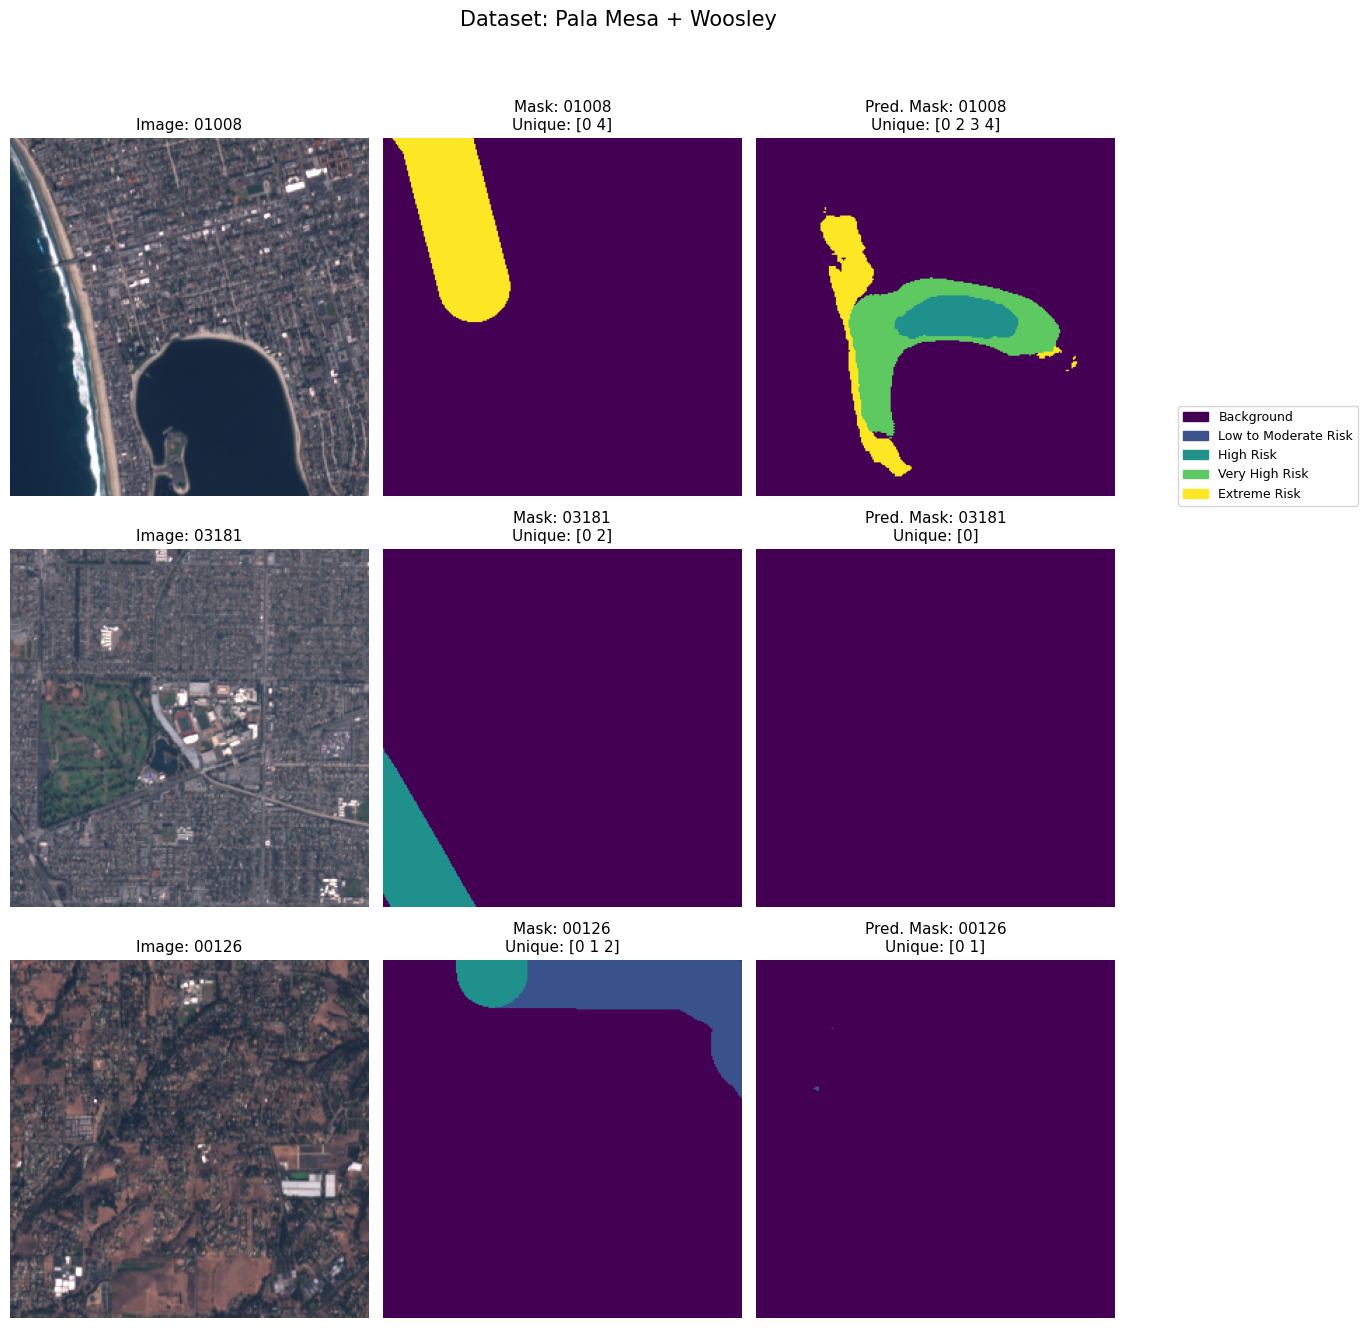

In [38]:
# Ensure that the model won't change now that it has finished training
model.trainable = False

# Define class labels for segmentation
class_labels = {0: "Background", 1: "Low to Moderate Risk", 2: "High Risk", 3: "Very High Risk", 4: "Extreme Risk"}

# Define the color map for visualizing the segmentation masks
class_color_map = "viridis"

# Test the model using the test_unet function from `unet.ipynb`
dataset_name = " + ".join(datasets.keys())

predicted_masks = test_unet(
    model,                           # The trained U-Net model
    images_test,                     # Test images
    masks_test,                      # Ground truth masks for the test images
    num_classes,                     # Number of classes in the segmentation task
    threshold=threshold,             # Threshold for binarizing the predicted masks
    image_names=names_test,          # Names of the test images
    display_count=3,                 # Number of test results to display
    class_labels=class_labels,       # Dictionary mapping class indices to names
    class_color_map=class_color_map, # Colormap for visualizing the masks
    dataset_name=dataset_name        # Label for the Dataset
)

In [39]:
# Save the predicted masks
SAVE_PREDICTED_MASKS = True  # Flag to indicate whether to save the predicted masks
predicted_masks_dir = Path(f"{model_dir}/predicted_masks/")  # Directory to save the predicted masks to as a Path object

if SAVE_PREDICTED_MASKS:
    save_predicted_masks(
        predicted_masks,            # Predicted masks to be saved
        predicted_masks_dir,        # Directory to save the predicted masks
        mask_names=names_test,      # Names of the test images corresponding to the predicted masks
        file_ext="tif"              # File extension for the saved masks
    )

Data saved in models/predicted_masks.


In [40]:
# Save files associated with the predicted masks, or other files of interest.
save_associated_files(
    masks_dir,               # Directory containing the original masks
    predicted_masks_dir,     # Directory to save the associated files
    file_ext="tfw",          # File extension of the associated files to be saved
    file_names=names_test,   # Names of the test images corresponding to the associated files
    names_map=names_map      # Mapping of original file names to trimmed names
)

The following files are missing from `names_map`: 
02937, 00306, 02977, 01686, 00615, 02826, 02962, 00179, 03697, 01163, 00111, 01032, 03179, 03649, 03532, 01885, 00886, 00527, 01565, 01358, 01438, 01146, 01791, 00495, 02775, 01802, 01813, 00191, 02121, 01279, 01916, 01021, 01364, 01088, 00126, 02473, 01008, 01525, 02155, 01962, 02679, 01917, 01570, 02411, 03088, 00722, 00113, 03342, 03332, 00474, 03486, 02619, 02994, 00563, 00706, 01950, 01001, 03123, 01902, 01812, 01431, 01056, 02040, 00545, 02434, 02689, 03629, 02924, 03181, 00522, 00536, 03231

Files saved to models/predicted_masks.
